### SPRINT-I
### PROJECT TITLE --- Rainfall Intelligence: Data Cleaning and Exploratory Analysis of Tamil Nadu Rainfall

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("E:\Rainfall-Intelligence\Dataset/rainfall_2021-2025.csv")
print("Dataset loaded successfully")

Dataset loaded successfully


## DATA CLEANING

In [5]:
print("No.of.Rows and Columns:", df.shape)

No.of.Rows and Columns: (161593, 20)


In [6]:
print("First 5 rows of the dataset:")
df.head(5)

First 5 rows of the dataset:


,SlNo,Station,Agency,State LGD Code,State,District LGD Code,District,Tehsil,Block,Village,River,Basin,Tributary,Subtributary,SubSubtributary,Local River,Latitude,Longitude,Data Acquisition Time,Telemetry Hourly Rainfall (mm)
0,1,Anaikidangu,Tamil Nadu SW GW,33,Tamil Nadu,575,Kanyakumari,-,-,-,-,-,-,-,-,-,8.2347,77.377894,09-01-2022 14:00,2.0
1,2,Anaikidangu,Tamil Nadu SW GW,33,Tamil Nadu,575,Kanyakumari,-,-,-,-,-,-,-,-,-,8.2347,77.377894,09-01-2022 15:00,15.0
2,3,Anaikidangu,Tamil Nadu SW GW,33,Tamil Nadu,575,Kanyakumari,-,-,-,-,-,-,-,-,-,8.2347,77.377894,09-01-2022 17:00,0.5
3,4,Anaikidangu,Tamil Nadu SW GW,33,Tamil Nadu,575,Kanyakumari,-,-,-,-,-,-,-,-,-,8.2347,77.377894,17-01-2022 17:00,0.5
4,5,Anaikidangu,Tamil Nadu SW GW,33,Tamil Nadu,575,Kanyakumari,-,-,-,-,-,-,-,-,-,8.2347,77.377894,12-02-2022 18:00,0.5


In [7]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 161593 entries, 0 to 161592
Data columns (total 20 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   SlNo                            161593 non-null  int64  
 1   Station                         161593 non-null  str    
 2   Agency                          161593 non-null  str    
 3   State LGD Code                  161593 non-null  int64  
 4   State                           161593 non-null  str    
 5   District LGD Code               161593 non-null  int64  
 6   District                        161593 non-null  str    
 7   Tehsil                          161593 non-null  str    
 8   Block                           161593 non-null  str    
 9   Village                         161593 non-null  str    
 10  River                           161593 non-null  str    
 11  Basin                           161593 non-null  str    
 12  Tribut

In [8]:
print("describe the dataset:")
df.describe().T

describe the dataset:


,count,mean,std,min,25%,50%,75%,max
SlNo,161593.0,80797.000000,46648.025362,1.000000,40399.000000,80797.000000,121195.000000,161593.000000
State LGD Code,161593.0,33.000000,0.000000,33.000000,33.000000,33.000000,33.000000,33.000000
District LGD Code,161593.0,596.026468,40.097736,568.000000,576.000000,586.000000,593.000000,733.000000
Latitude,161593.0,10.777618,1.364114,8.119722,9.783333,10.744444,11.903056,13.331389
Longitude,161593.0,78.444517,0.955264,76.422778,77.672778,78.475000,79.238889,80.279167
Telemetry Hourly Rainfall (mm),161593.0,8.333944,121.785825,0.500000,0.500000,1.000000,3.000000,16750.000000


In [9]:
print("Any Null values in the dataset:")
df.isnull().sum()

Any Null values in the dataset:


SlNo                              0
Station                           0
Agency                            0
State LGD Code                    0
State                             0
District LGD Code                 0
District                          0
Tehsil                            0
Block                             0
Village                           0
River                             0
Basin                             0
Tributary                         0
Subtributary                      0
SubSubtributary                   0
Local River                       0
Latitude                          0
Longitude                         0
Data Acquisition Time             0
Telemetry Hourly Rainfall (mm)    0
dtype: int64

In [10]:
print("Any Duplicate values in the dataset:")
df.duplicated().sum()

Any Duplicate values in the dataset:


np.int64(0)

In [11]:
df["Data Acquisition Time"] = pd.to_datetime(
    df["Data Acquisition Time"],
    dayfirst=True,
    errors="coerce"
)

In [12]:
rainfall_col = "Telemetry Hourly Rainfall (mm)"

df[rainfall_col] = pd.to_numeric(
    df[rainfall_col],
    errors="coerce"
)

In [13]:
print("Start Date:")
print(df["Data Acquisition Time"].min())

print("\nEnd Date:")
print(df["Data Acquisition Time"].max())

Start Date:
2021-08-09 14:00:00

End Date:
2025-12-31 23:00:00


In [14]:
print("Number of stations:", df["Station"].nunique())
print("Number of districts:", df["District"].nunique())
df["Year"] = df["Data Acquisition Time"].dt.year
print("Years in the dataset:", df["Year"].unique())

Number of stations: 145
Number of districts: 36
Years in the dataset: [2022 2023 2024 2025 2021]


In [15]:
rainfall_summary = df[rainfall_col].describe()

print(rainfall_summary)

count    161593.000000
mean          8.333944
std         121.785825
min           0.500000
25%           0.500000
50%           1.000000
75%           3.000000
max       16750.000000
Name: Telemetry Hourly Rainfall (mm), dtype: float64


## EDA Process

In [16]:
summary = pd.DataFrame({
    "Metric": [
        "Minimum",
        "Average",
        "Median",
        "Maximum",
        "25th Percentile",
        "75th Percentile"
    ],
    "Rainfall (mm)": [
        df[rainfall_col].min(),
        df[rainfall_col].mean(),
        df[rainfall_col].median(),
        df[rainfall_col].max(),
        df[rainfall_col].quantile(0.25),
        df[rainfall_col].quantile(0.75)
    ]
})

print(summary)

            Metric  Rainfall (mm)
0          Minimum       0.500000
1          Average       8.333944
2           Median       1.000000
3          Maximum   16750.000000
4  25th Percentile       0.500000
5  75th Percentile       3.000000


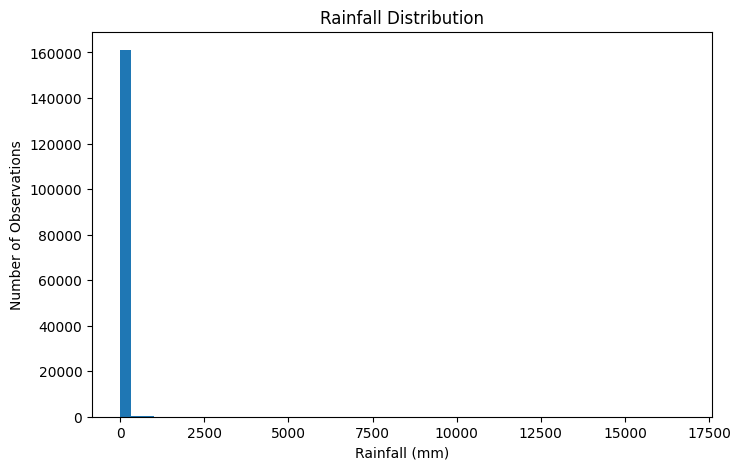

In [17]:
plt.figure(figsize=(8, 5))

plt.hist(
    df[rainfall_col],
    bins=50
)

plt.xlabel("Rainfall (mm)")
plt.ylabel("Number of Observations")
plt.title("Rainfall Distribution")

plt.show()

In [18]:
df["Year"] = df["Data Acquisition Time"].dt.year
df["Month"] = df["Data Acquisition Time"].dt.month
df["Month_Name"] = df["Data Acquisition Time"].dt.month_name()

In [19]:
year_summary = df.groupby("Year")[rainfall_col].agg(
    Records="count",
    Average="mean",
    Median="median",
    Maximum="max"
).round(2)

print(year_summary)

      Records  Average  Median  Maximum
Year                                   
2021     1728    22.07     1.5  15444.0
2022    32812    12.36     1.0  16750.0
2023    41018    10.93     1.0   7693.5
2024    49581     5.92     1.0   9198.5
2025    36454     4.43     1.0   4707.0


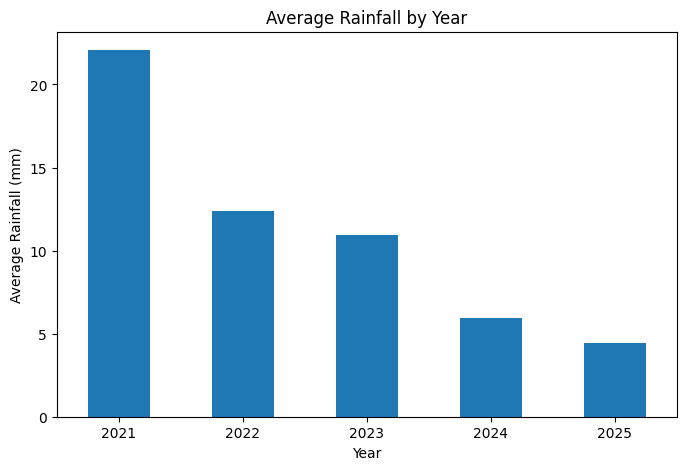

In [20]:
year_summary["Average"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Year")
plt.ylabel("Average Rainfall (mm)")
plt.title("Average Rainfall by Year")
plt.xticks(rotation=0)
plt.show()

In [21]:
month_summary = df.groupby("Month")[rainfall_col].agg(
    Records="count",
    Average="mean",
    Median="median",
    Maximum="max"
).round(2)

print(month_summary)

       Records  Average  Median  Maximum
Month                                   
1         5269    12.01     1.0   2400.0
2         2369     3.89     1.0    994.5
3         4783     8.43     1.0   7851.0
4         6472     6.28     1.0    913.0
5        14669     6.09     1.0   2177.0
6        12044     7.64     1.0   7693.5
7        12422    16.83     1.0  16750.0
8        15893     6.73     1.0   4707.0
9        12548     8.76     1.0  15444.0
10       23738     8.40     1.0   5756.0
11       29630     9.12     1.0   9198.5
12       21756     5.35     1.0   3014.0


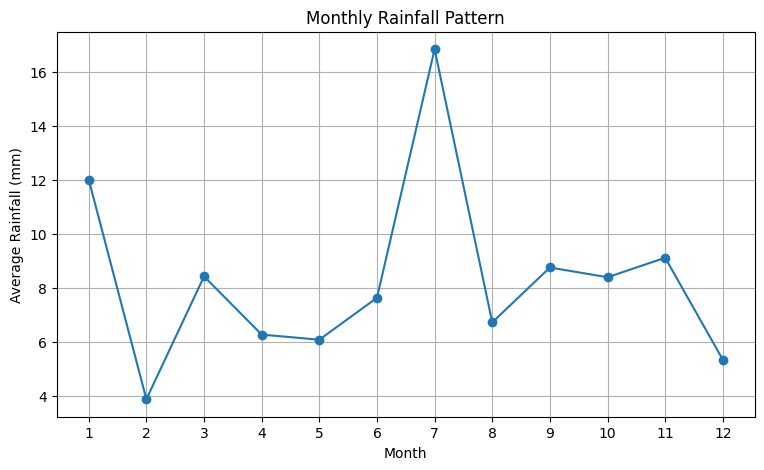

In [22]:
month_summary["Average"].plot(
    kind="line",
    marker="o",
    figsize=(9, 5)
)

plt.xlabel("Month")
plt.ylabel("Average Rainfall (mm)")
plt.title("Monthly Rainfall Pattern")
plt.xticks(range(1, 13))
plt.grid()
plt.show()

In [23]:
district_summary = df.groupby("District")[rainfall_col].agg(
    Records="count",
    Average="mean",
    Median="median",
    Maximum="max"
).sort_values(
    "Average",
    ascending=False
).round(2)

print(district_summary)

                 Records  Average  Median  Maximum
District                                          
Nilgiris            2755    64.45     1.0  16750.0
Ramanathapuram      8272    22.09     1.5   7851.0
Kallakurichi        2014    17.47     1.0   2850.5
Dindigul            4017    16.03     1.5   3768.5
Tirupathur          2260    15.61     1.0   8660.5
Chengalpattu        2499    14.63     1.5   7693.5
Pudukkottai         6319    12.82     1.0   2400.0
Ariyalur            2482    12.74     2.0    624.5
Tiruppur            4874     9.36     1.0   7314.5
Karur               5010     9.36     1.0   3341.0
Tirunelveli         5885     9.26     1.0  15444.0
Nagapattinam        3372     8.28     1.5    714.5
Virudhunagar        6247     8.13     1.0   4707.0
Salem               2068     7.85     1.0   3462.0
Tiruvarur           4846     6.86     1.0   1019.5
Thanjavur           8990     6.39     1.0   9198.5
Cuddalore           4871     6.23     1.0   5208.0
Krishnagiri         5608     5.

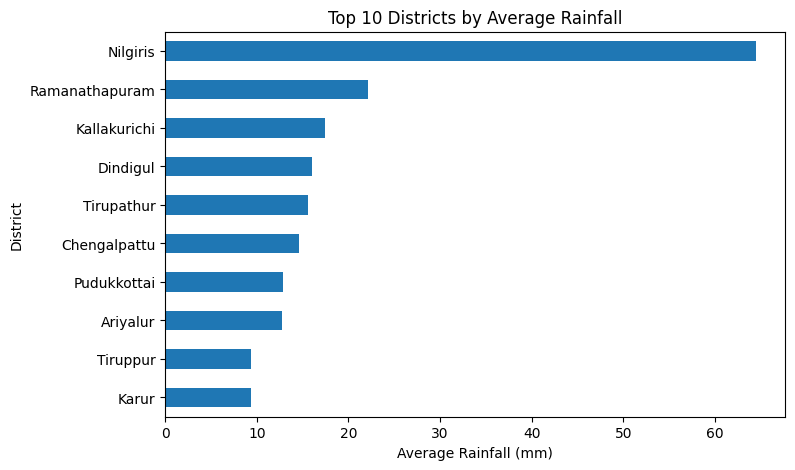

In [24]:
top_districts = district_summary.head(10)

top_districts["Average"].sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.xlabel("Average Rainfall (mm)")
plt.ylabel("District")
plt.title("Top 10 Districts by Average Rainfall")

plt.show()

In [25]:
station_summary = df.groupby("Station")[rainfall_col].agg(
    Records="count",
    Average="mean",
    Median="median",
    Maximum="max"
).sort_values(
    "Average",
    ascending=False
).round(2)

print(station_summary)

                     Records  Average  Median  Maximum
Station                                               
Gudalore_1              1582   104.49     1.0  16750.0
Thiruvadanai_1          1848    75.68     4.0   2246.5
Cheranmahadevi           924    37.51     1.0  15444.0
Natham_1                1355    35.40     1.5   3768.5
Sikkal_1                 702    26.33     1.0   7851.0
...                      ...      ...     ...      ...
Gudalore_M              1373     1.83     0.5     65.0
Ramanadhapuram -ARG     1396     1.82     0.5     39.5
Vidur Anicut            2065     1.70     0.5    156.0
Bodinayakkanur_1        1517     1.61     0.5     38.5
Pattukottai_1           2047     1.52     0.5     79.5

[145 rows x 4 columns]


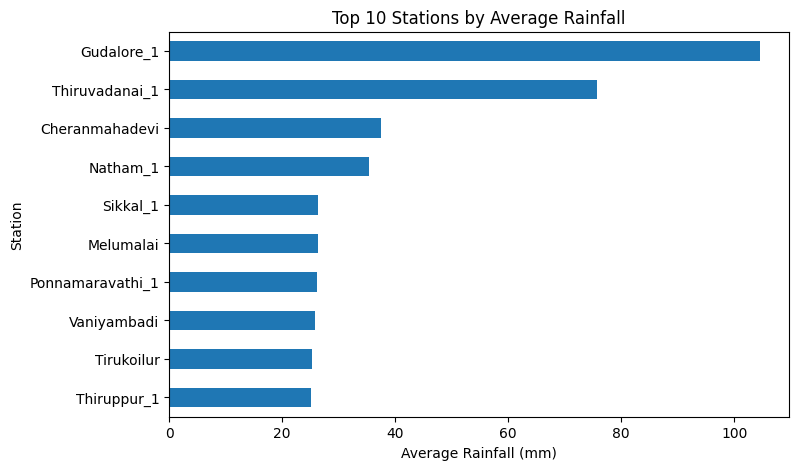

In [26]:
top_stations = station_summary.head(10)

top_stations["Average"].sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.xlabel("Average Rainfall (mm)")
plt.ylabel("Station")
plt.title("Top 10 Stations by Average Rainfall")

plt.show()

In [27]:
extreme_100 = df[df[rainfall_col] >= 100]

extreme_1000 = df[df[rainfall_col] >= 1000]

print("Rainfall >= 100 mm:", len(extreme_100))
print("Rainfall >= 1000 mm:", len(extreme_1000))

Rainfall >= 100 mm: 1392
Rainfall >= 1000 mm: 135


In [28]:
top_extreme = df.nlargest(
    20,
    rainfall_col
)[
    [
        "Station",
        "District",
        "Data Acquisition Time",
        rainfall_col
    ]
]

top_extreme

,Station,District,Data Acquisition Time,Telemetry Hourly Rainfall (mm)
22548,Gudalore_1,Nilgiris,2022-07-04 15:00:00,16750.0
12453,Cheranmahadevi,Tirunelveli,2021-09-28 18:00:00,15444.0
12455,Cheranmahadevi,Tirunelveli,2021-09-28 23:00:00,15053.0
22566,Gudalore_1,Nilgiris,2022-07-05 09:00:00,10298.5
92444,Peravoorani_1,Thanjavur,2024-11-23 17:00:00,9198.5
22522,Gudalore_1,Nilgiris,2022-07-03 13:00:00,8834.0
148984,Vaniyambadi,Tirupathur,2022-11-11 18:00:00,8660.5
22567,Gudalore_1,Nilgiris,2022-07-05 10:00:00,8247.5
124636,Sikkal_1,Ramanathapuram,2024-03-16 07:00:00,7851.0
64201,Madurantakam,Chengalpattu,2023-06-22 18:00:00,7693.5


In [29]:
extreme_year = (
    extreme_100
    .groupby("Year")
    .size()
    .sort_index()
)

print(extreme_year)

Year
2021      3
2022    383
2023    603
2024    280
2025    123
dtype: int64


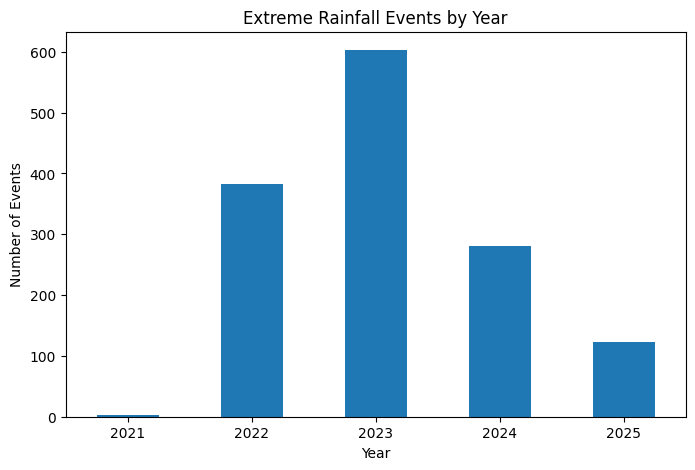

In [30]:
extreme_year.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Year")
plt.ylabel("Number of Events")
plt.title("Extreme Rainfall Events by Year")
plt.xticks(rotation=0)

plt.show()

In [31]:
station_coverage = (
    df.groupby("Station")
    .size()
    .sort_values(ascending=False)
)

station_coverage

Station
Sholaiyur               4943
Manalmedu_1             2149
Vidur Anicut            2065
Pattukottai_1           2047
Perunchani Reservoir    2046
                        ... 
Kulasekarapattinam       613
Uthampalayam             608
Melumalai                589
Valathi                  573
Kalingarayan -ARG        554
Length: 145, dtype: int64

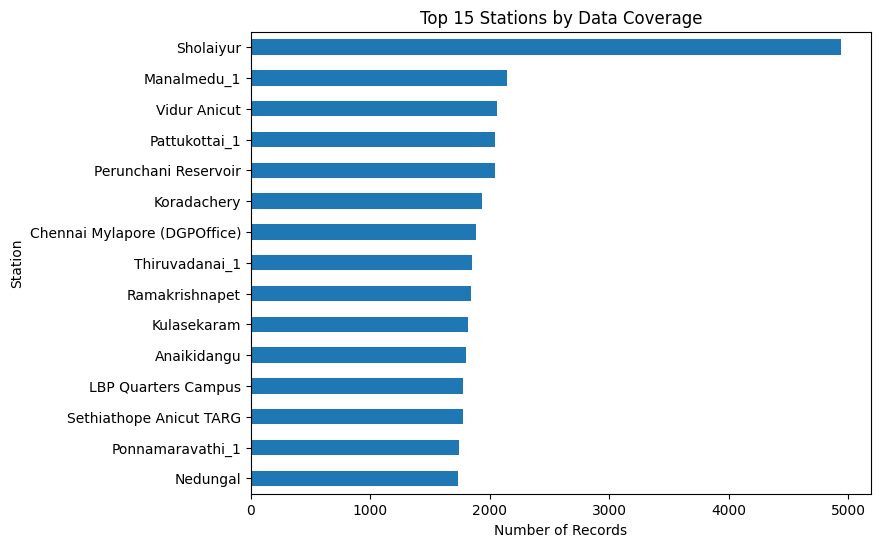

In [32]:
station_coverage.head(15).sort_values().plot(
    kind="barh",
    figsize=(8, 6)
)

plt.xlabel("Number of Records")
plt.ylabel("Station")
plt.title("Top 15 Stations by Data Coverage")

plt.show()

Year
2021     1728
2022    32812
2023    41018
2024    49581
2025    36454
dtype: int64


(array([0, 1, 2, 3, 4]),
 [Text(0, 0, '2021'),
  Text(1, 0, '2022'),
  Text(2, 0, '2023'),
  Text(3, 0, '2024'),
  Text(4, 0, '2025')])

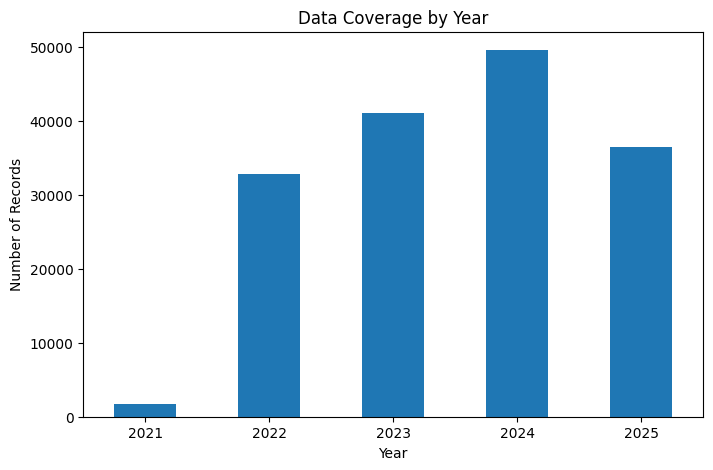

In [33]:
year_coverage = df.groupby("Year").size()

print(year_coverage)
year_coverage.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Year")
plt.ylabel("Number of Records")
plt.title("Data Coverage by Year")
plt.xticks(rotation=0)


In [34]:
df["Date"] = df["Data Acquisition Time"].dt.date

station_days = df[
    ["Station", "Date"]
].drop_duplicates()

print(
    "Unique Station-Day combinations:",
    len(station_days)
)

Unique Station-Day combinations: 42975


In [35]:
columns_to_remove = [
    "Tehsil",
    "Block",
    "Village",
    "River",
    "Basin",
    "Tributary",
    "Subtributary",
    "SubSubtributary"
]

df = df.drop(columns=columns_to_remove, errors="ignore")

print("Remaining columns:")
print(df.columns.tolist())

df.shape

Remaining columns:
['SlNo', 'Station', 'Agency', 'State LGD Code', 'State', 'District LGD Code', 'District', 'Local River', 'Latitude', 'Longitude', 'Data Acquisition Time', 'Telemetry Hourly Rainfall (mm)', 'Year', 'Month', 'Month_Name', 'Date']


(161593, 16)

In [36]:
output_file = "rainfall_eda_2021_2025.csv"

df.to_csv(
    output_file,
    index=False
)

print("EDA dataset saved successfully!")

EDA dataset saved successfully!


In [37]:
print("========== PROJECT SUMMARY ==========")

print("Total Records:", len(df))

print("Number of Stations:",
      df["Station"].nunique())

print("Number of Districts:",
      df["District"].nunique())

print("Average Rainfall:",
      round(df[rainfall_col].mean(), 2), "mm")

print("Median Rainfall:",
      round(df[rainfall_col].median(), 2), "mm")

print("Maximum Rainfall:",
      df[rainfall_col].max(), "mm")

print("Rainfall >= 100 mm:",
      len(extreme_100))

print("Rainfall >= 1000 mm:",
      len(extreme_1000))

print("Unique Station-Day combinations:",
      len(station_days))

========== PROJECT SUMMARY ==========
Total Records: 161593
Number of Stations: 145
Number of Districts: 36
Average Rainfall: 8.33 mm
Median Rainfall: 1.0 mm
Maximum Rainfall: 16750.0 mm
Rainfall >= 100 mm: 1392
Rainfall >= 1000 mm: 135
Unique Station-Day combinations: 42975
